In [1]:
import yaml
import numpy as np
from TraceSimulator import InjectionTraceSimulator

import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve
from OptimumFilter import *

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/v2_short.yaml')
its = InjectionTraceSimulator(config)

def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))
    
    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [3]:
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/wk20/template_27k.npy")
noise_psd    = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
fs           = 3906250
vac_of = OptimumFilter(vac_template, noise_psd, fs)

In [4]:
amps, _ = vac_of.sliding_fit(trace[0][37], hop=1, reanchor_every=None, chisq_mode="none")

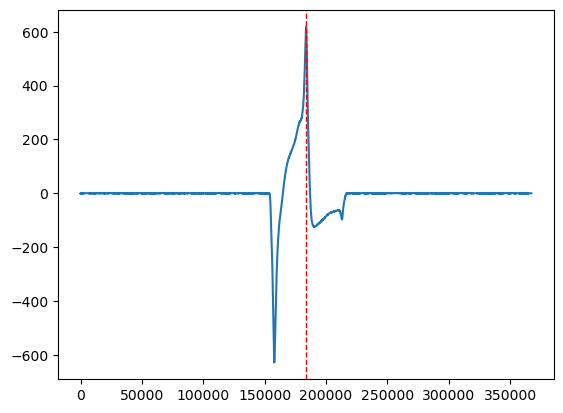

In [5]:
plt.plot(amps)
plt.axvline(x=183616, color='red', linestyle='--', linewidth=1)  # vertical line
plt.show()

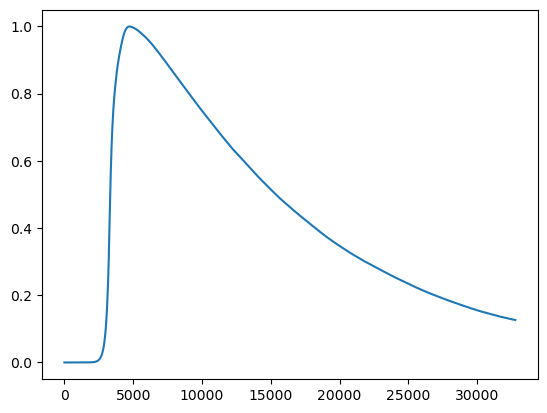

In [7]:
plt.plot(vac_template)


E=5: n=50, mean=2692.54, std=73273.32, min=-147401, max=183616
E=10: n=50, mean=-3.06, std=1098.99, min=-1161, max=5595
E=15: n=50, mean=-168.00, std=433.27, min=-584, max=2722
E=20: n=50, mean=-194.90, std=87.57, min=-375, max=15


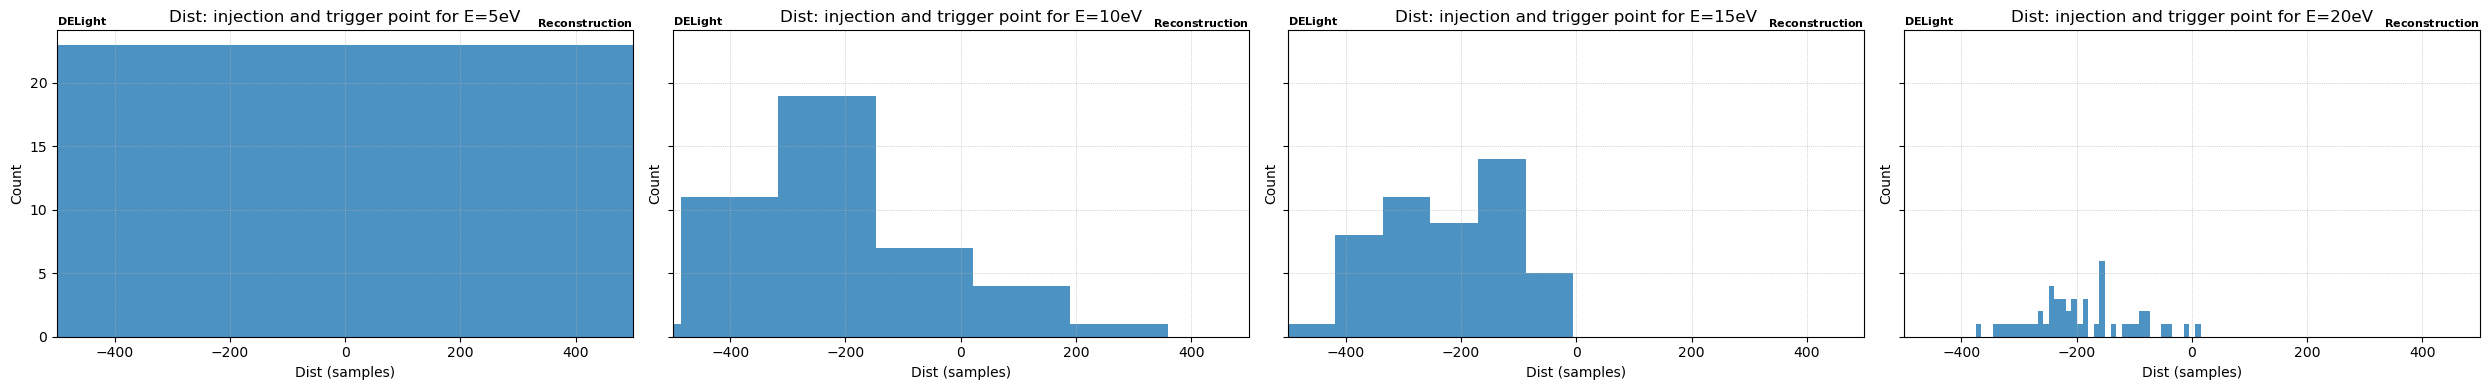

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
energies = [5, 10, 15, 20]          # E values to test
repeats_per_E = 50         # how many times to repeat per energy
target_index = 183616       # reference index
channel = 37                # which channel to use
hop = 1

# Store differences per energy
diffs_by_E = {E: [] for E in energies}

for E in energies:
    for _ in range(repeats_per_E):
        # Generate one long trace with signal mask
        trace, mask, idx = its.generate(
            E=E,
            x=0, y=0, z=-1700,
            no_noise=False,
            type_recoil='NR',
            quantize=False,
            phonon_only=False,
            long_trace_samples=400000,
            return_signal_mask=True
        )

        # Take the requested channel from the first trace set
        ch_trace = trace[0][channel]

        # Sliding fit to get amplitudes
        amps, _ = vac_of.sliding_fit(
            ch_trace,
            hop=hop,
            reanchor_every=None,
            chisq_mode="none"
        )

        # Index of max amplitude and the difference to the target index
        peak_idx = int(np.argmax(amps))
        diff = target_index - peak_idx
        diffs_by_E[E].append(diff)

# Convert to arrays for convenience
for E in diffs_by_E:
    diffs_by_E[E] = np.asarray(diffs_by_E[E])

# --- Optional quick stats ---
for E in energies:
    arr = diffs_by_E[E]
    print(f"E={E}: n={arr.size}, mean={arr.mean():.2f}, std={arr.std(ddof=1):.2f}, "
          f"min={arr.min()}, max={arr.max()}")

# --- Plot histograms ---
fig, axes = plt.subplots(1, 4, figsize=(25, 4), sharey=True)
bins = 40  # adjust as needed

for ax, E in zip(axes, energies):
    ax.hist(diffs_by_E[E], bins=bins, alpha=0.8)
    ax.set_title(f"Dist: injection and trigger point for E={E}eV")
    ax.set_xlabel("Dist (samples)")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle=":", linewidth=0.5)
    
    # Fix x-axis range
    ax.set_xlim(-500, 500)

    # Add "shoulder" labels
    ax.text(0.0, 1.005, r"$\mathbf{DELight}$",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=8)
    ax.text(1.0, 1.005, r"$\mathbf{Reconstruction}$",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()



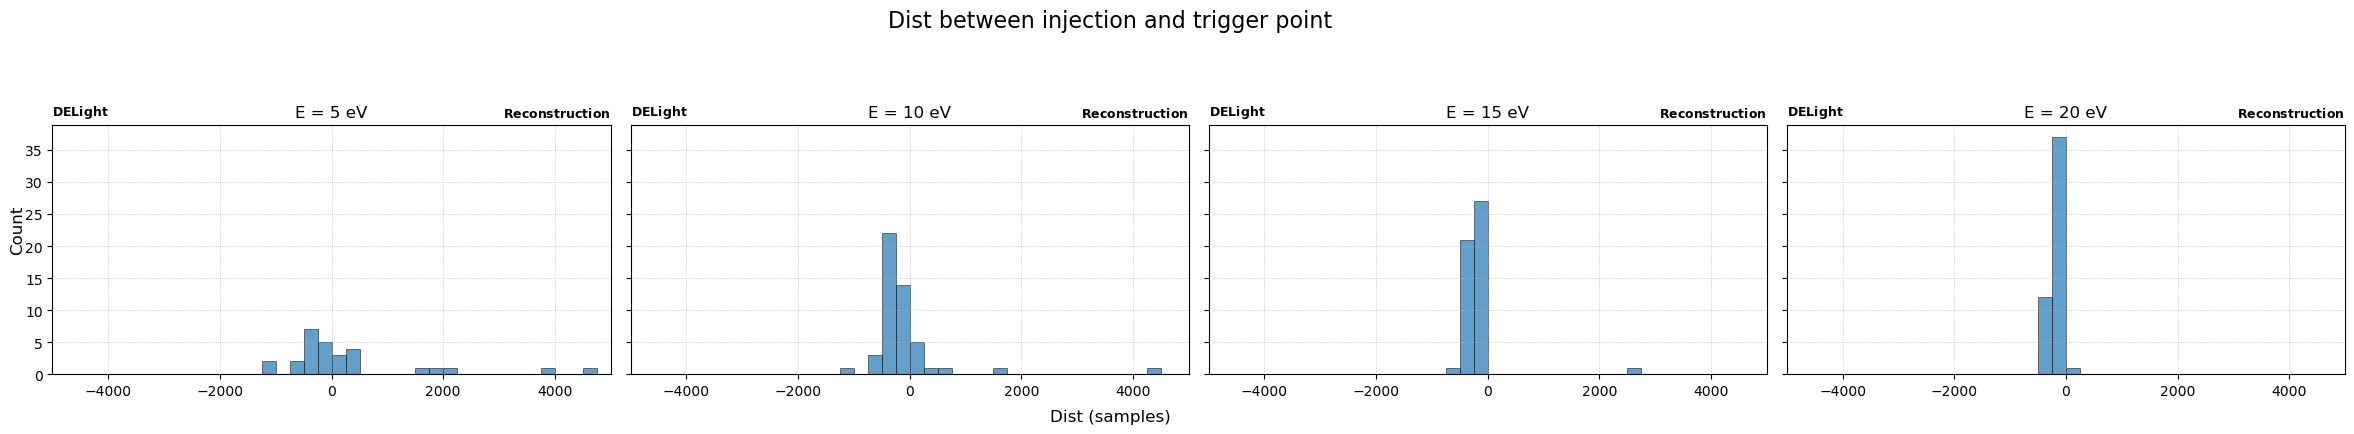

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(25, 4), sharey=True)

# global binning
x_min, x_max = -5000, 5000
bins = np.linspace(x_min, x_max, 41)

# find global max height for consistent y-limits
all_counts = [np.histogram(diffs_by_E[E], bins=bins)[0] for E in energies]
y_max = max([counts.max() for counts in all_counts])

for ax, E in zip(axes, energies):
    ax.hist(diffs_by_E[E], bins=bins, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.set_title(f"E = {E} eV", fontsize=12)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max * 1.05)
    ax.grid(True, linestyle=":", linewidth=0.5)

    # shoulder labels
    ax.text(0.0, 1.02, r"$\mathbf{DELight}$", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9)
    ax.text(1.0, 1.02, r"$\mathbf{Reconstruction}$", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9)

# shared labels
fig.text(0.5, 0.02, "Dist (samples)", ha="center", fontsize=12)
fig.text(0.06, 0.5, "Count", va="center", rotation="vertical", fontsize=12)

# big title
fig.suptitle("Dist between injection and trigger point", fontsize=16, y=1.05)

plt.tight_layout(rect=[0.06, 0.04, 1, 0.95])  # leave room for big title
plt.show()


23k: n=50, mean=3819.02, std=140.82, min=3585, max=4269
25k: n=50, mean=1837.52, std=113.46, min=1669, max=2097
27k: n=50, mean=-225.62, std=95.10, min=-382, max=19


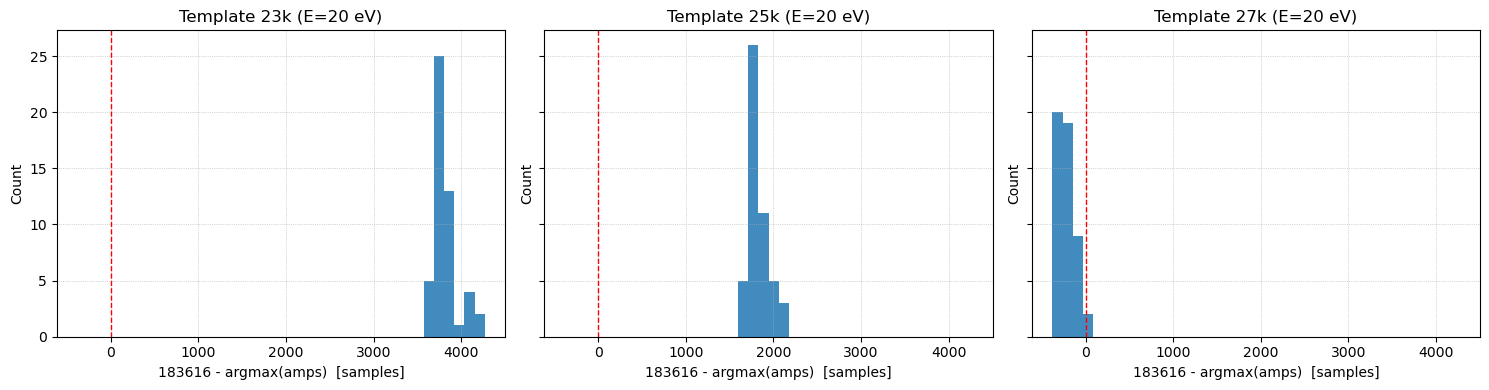

In [43]:
import numpy as np
import matplotlib.pyplot as plt
# from your_module import OptimumFilter  # <- make sure this import matches your project

# -----------------------------
# Config
# -----------------------------
E = 20
repeats = 50
target_index = 183616
channel = 37
hop = 1
fs = 3_906_250  # Hz

# -----------------------------
# Load templates & PSD
# -----------------------------
# Adjust these paths if needed. Assumes you already saved 23k/25k/27k templates as .npy
tpl_23k = np.load("template_23k.npy")
tpl_25k = np.load("template_25k.npy")
tpl_27k = np.load("template_27k.npy")

noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")

# -----------------------------
# Register OFs (one per template)
# -----------------------------
of_bank = {
    "23k": OptimumFilter(tpl_23k, noise_psd, fs),
    "25k": OptimumFilter(tpl_25k, noise_psd, fs),
    "27k": OptimumFilter(tpl_27k, noise_psd, fs),
}

# -----------------------------
# Collect diffs per template
# -----------------------------
diffs_by_template = {name: [] for name in of_bank.keys()}

for _ in range(repeats):
    # Generate one long trace with signal mask at E=20 eV
    trace, mask, idx = its.generate(
        E=E,
        x=0, y=0, z=-1700,
        no_noise=False,
        type_recoil='NR',
        quantize=False,
        phonon_only=False,
        long_trace_samples=400000,
        return_signal_mask=True
    )

    ch_trace = trace[0][channel]

    # Fit with each template-specific OF
    for name, of_obj in of_bank.items():
        amps, _ = of_obj.sliding_fit(
            ch_trace,
            hop=hop,
            reanchor_every=None,
            chisq_mode="none"
        )
        peak_idx = int(np.argmax(amps))
        diff = target_index - peak_idx
        diffs_by_template[name].append(diff)

# Convert to arrays & print quick stats
for name in list(diffs_by_template):
    arr = np.asarray(diffs_by_template[name])
    diffs_by_template[name] = arr
    print(f"{name}: n={arr.size}, mean={arr.mean():.2f}, std={arr.std(ddof=1):.2f}, "
          f"min={arr.min()}, max={arr.max()}")

# -----------------------------
# Plot histograms (separate, shared bins)
# -----------------------------
all_diffs = np.concatenate(list(diffs_by_template.values()))
nbins = 40
bins = np.linspace(all_diffs.min() - 0.5, all_diffs.max() + 0.5, nbins + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, ["23k", "25k", "27k"]):
    ax.hist(diffs_by_template[name], bins=bins, alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)  # zero = perfect alignment
    ax.set_title(f"Template {name} (E={E} eV)")
    ax.set_xlabel("183616 - argmax(amps)  [samples]")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.show()


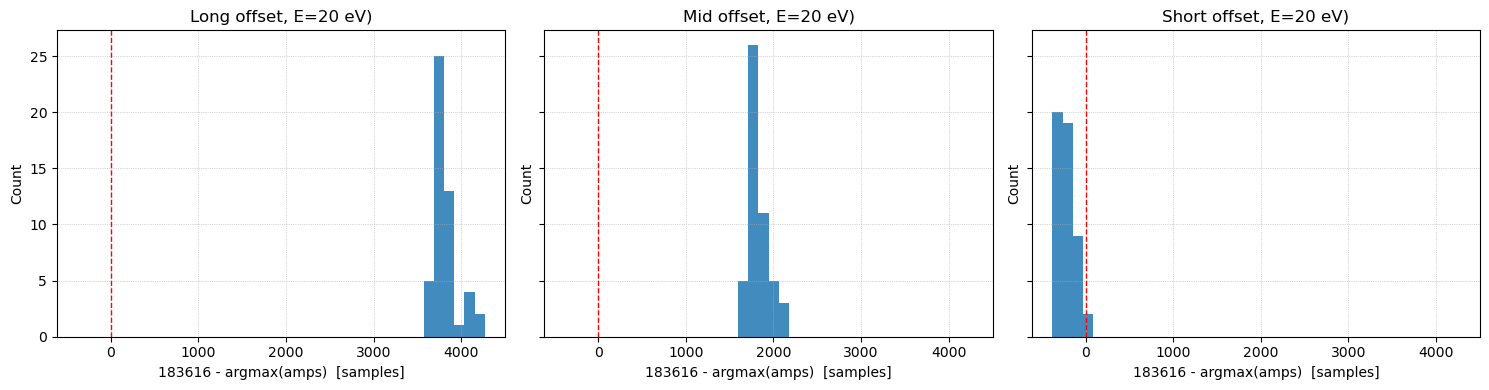

In [48]:
# Map display labels -> template keys
offset_order = [
    ("Long offset",  "23k"),
    ("Mid offset",   "25k"),
    ("Short offset", "27k"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, key) in zip(axes, offset_order):
    ax.hist(diffs_by_template[key], bins=bins, alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)  # zero = perfect alignment
    ax.set_title(f"{label}, E={E} eV)")
    ax.set_xlabel("183616 - argmax(amps)  [samples]")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.show()


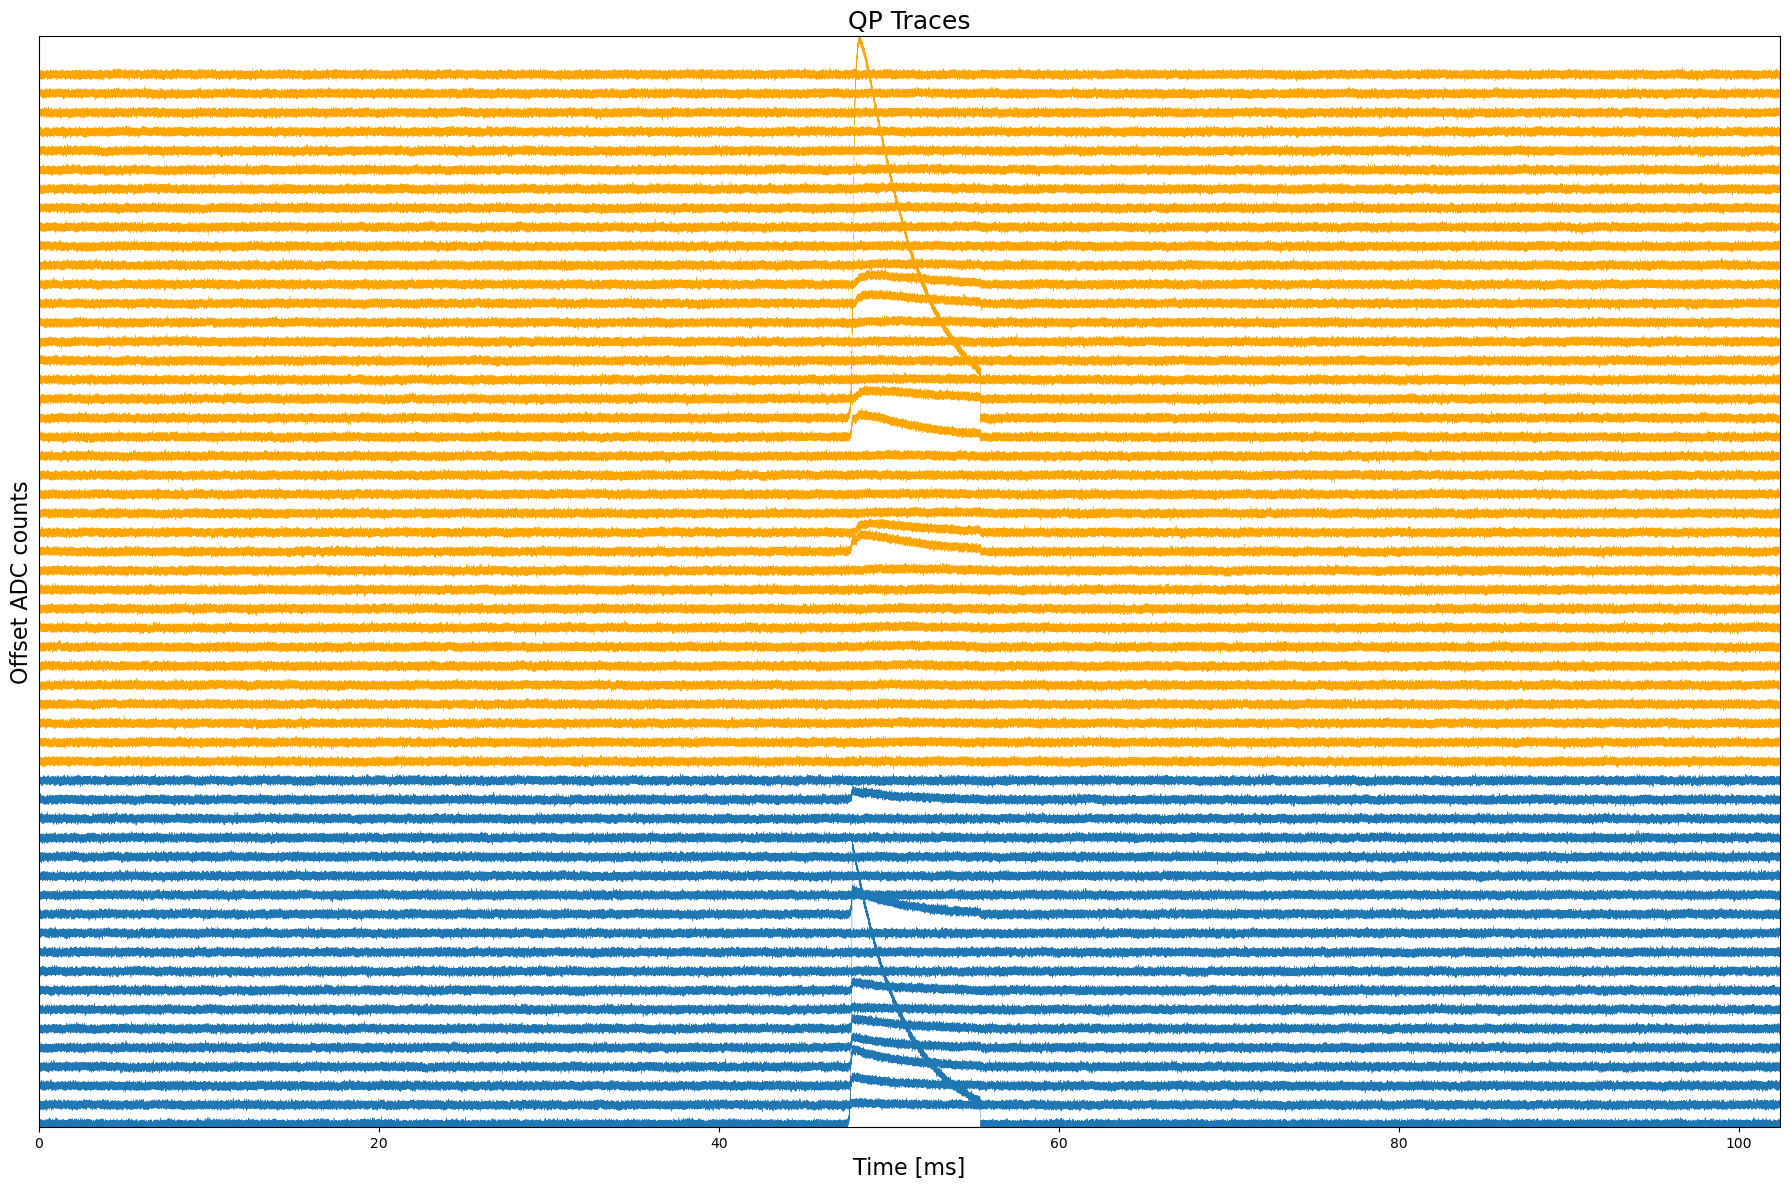

In [36]:
plot_traces(trace)



In [14]:
mask

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False]])

In [20]:
mask[0][37]

True